<a href="https://colab.research.google.com/github/joaopedrodelcolli/analise-album-figurinhas/blob/main/simulacao_colecionador_figurinhas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<>:46: SyntaxWarning: invalid escape sequence '\m'
<>:46: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_8443/3450780962.py:46: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_title(f'Probabilidade Poisson ($\mu$={mu:.1f})', fontsize=12)


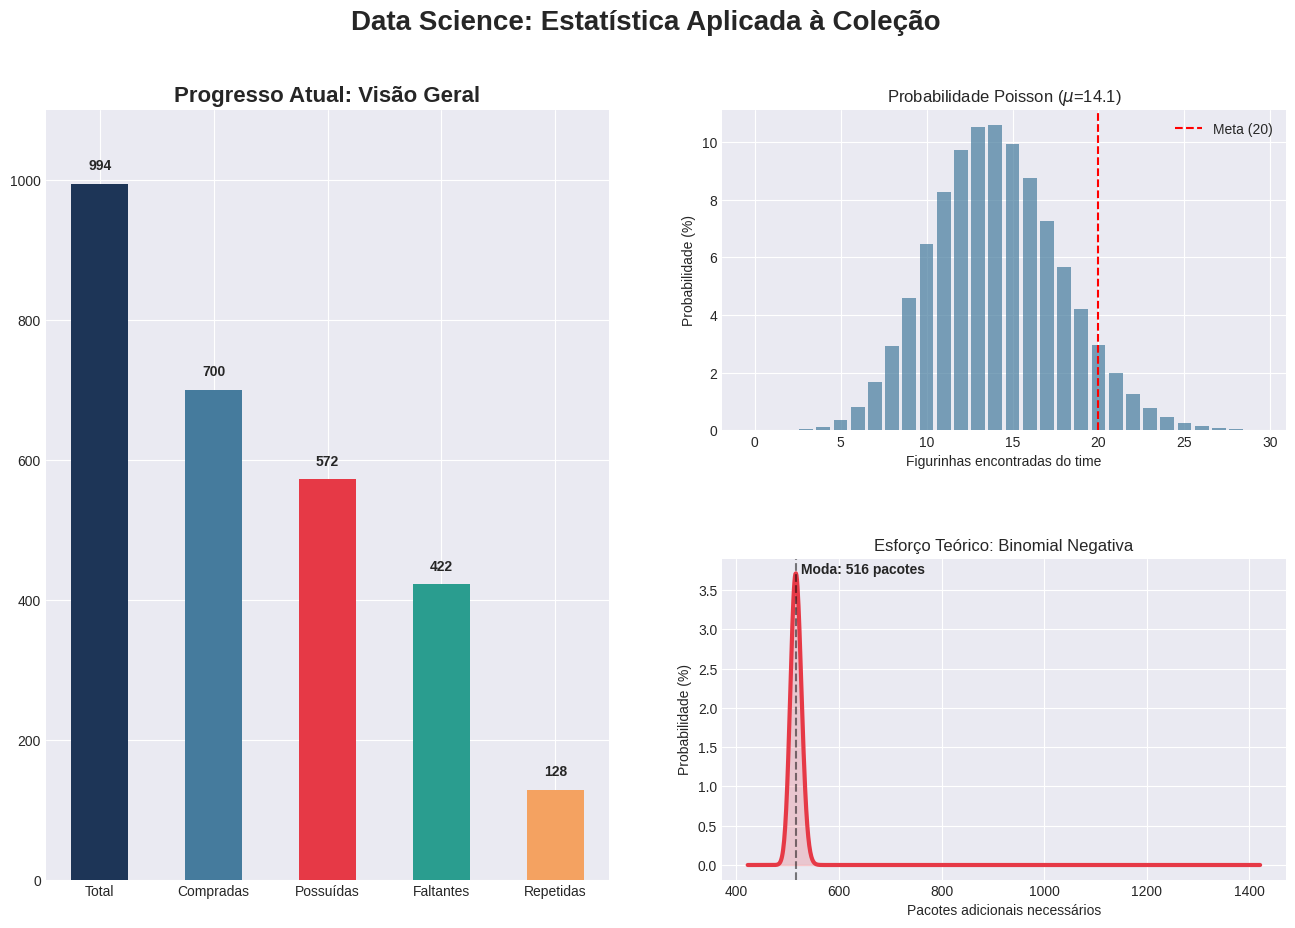

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import poisson, nbinom

# Configuração de Estilo Visual
plt.style.use('seaborn-v0_8-darkgrid')

# ==============================================================================
# 1. ANÁLISE ANALÍTICA (Modelagem Teórica)
# ==============================================================================

# Definição dos parâmetros do álbum
np.random.seed(42)
total_album = 994
comprei = 700
ja_possuo = 572
faltam = total_album - ja_possuo
repetidas = 128
taxa_sucesso = ja_possuo / comprei

# Criação da figura com subplots
fig1 = plt.figure(figsize=(16, 10))
gs = fig1.add_gridspec(2, 2, hspace=0.4, wspace=0.2)

# --- 1.1 Funil: Cenário Real ---
ax1 = fig1.add_subplot(gs[:, 0])
etapas = ['Total', 'Compradas', 'Possuídas', 'Faltantes', 'Repetidas']
valores = [total_album, comprei, ja_possuo, faltam, repetidas]
cores = ['#1D3557', '#457B9D', '#E63946', '#2A9D8F', '#F4A261']

bars = ax1.bar(etapas, valores, color=cores, width=0.5)
ax1.set_title('Progresso Atual: Visão Geral', fontsize=16, fontweight='bold')
ax1.set_ylim(0, 1100)
for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 20, f'{yval}', ha='center', fontweight='bold')

# --- 1.2 Poisson: Probabilidade de encontrar 20 figurinhas de um time ---
ax2 = fig1.add_subplot(gs[0, 1])
mu = (20 / total_album) * comprei
x_p = np.arange(0, 30)
# Multiplicado por 100 para representar porcentagem no eixo Y
probs_poisson = poisson.pmf(x_p, mu) * 100

ax2.bar(x_p, probs_poisson, color='#457B9D', alpha=0.7)
ax2.set_title(f'Probabilidade Poisson ($\mu$={mu:.1f})', fontsize=12)
ax2.axvline(20, color='red', linestyle='--', label='Meta (20)')
ax2.set_xlabel('Figurinhas encontradas do time')
ax2.set_ylabel('Probabilidade (%)')
ax2.legend()

# --- 1.3 Binomial Negativa: Esforço estimado ---
ax3 = fig1.add_subplot(gs[1, 1])
k = faltam
p = taxa_sucesso
x_n = np.arange(k, k + 1000)
y_n = nbinom.pmf(x_n - k, k, p) * 100

ax3.plot(x_n, y_n, color='#E63946', linewidth=3)
ax3.fill_between(x_n, y_n, color='#E63946', alpha=0.2)
ax3.set_title('Esforço Teórico: Binomial Negativa', fontsize=12)
ax3.set_xlabel('Pacotes adicionais necessários')
ax3.set_ylabel('Probabilidade (%)')

# Identificação da moda (ponto mais provável)
pico_x = x_n[np.argmax(y_n)]
ax3.axvline(pico_x, color='black', linestyle='--', alpha=0.5)
ax3.text(pico_x + 10, max(y_n), f'Moda: {pico_x} pacotes', fontsize=10, fontweight='bold')

plt.suptitle('Data Science: Estatística Aplicada à Coleção', fontsize=20, fontweight='bold')
plt.show()

Executando Simulação de Monte Carlo (5.000 iterações)...


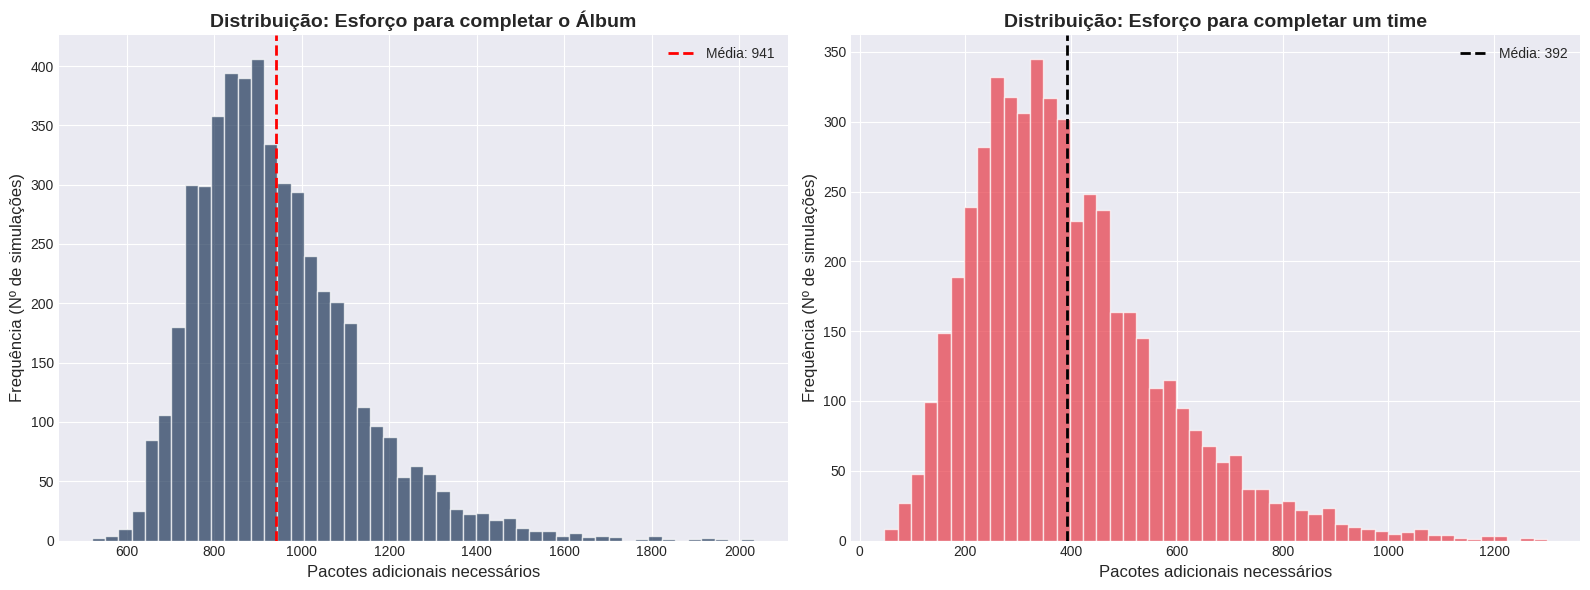

In [7]:
# ==============================================================================
# 2. ANÁLISE ESTOCÁSTICA (Simulação de Monte Carlo)
# ==============================================================================

# Parâmetros de Simulação
simulacoes = 5000
pacotes_para_completar_album = []
pacotes_para_completar_time = []

print("Executando Simulação de Monte Carlo (5.000 iterações)...")

for i in range(simulacoes):
    # Inicializa álbum condicionado ao estado atual
    album = np.zeros(total_album)
    album[np.random.choice(total_album, ja_possuo, replace=False)] = 1

    time_indices = np.arange(0, 20)
    pacotes = 0
    time_completo = False

    while np.sum(album) < total_album:
        # Sorteia 7 figurinhas por pacote
        album[np.random.randint(0, total_album, 7)] = 1
        pacotes += 1

        # Monitora a conclusão do time específico
        if not time_completo and np.sum(album[time_indices]) == 20:
            pacotes_para_completar_time.append(pacotes)
            time_completo = True

    pacotes_para_completar_album.append(pacotes)

# Visualização da Simulação com legendas profissionais e descritivas
fig2, (ax4, ax5) = plt.subplots(1, 2, figsize=(16, 6))

# --- Gráfico 1: Álbum Completo ---
mean_album = np.mean(pacotes_para_completar_album)
ax4.hist(pacotes_para_completar_album, bins=50, color='#1D3557', alpha=0.7, edgecolor='white')
# Adiciona linha vertical da média
ax4.axvline(mean_album, color='red', linestyle='dashed', linewidth=2, label=f'Média: {int(mean_album)}')
ax4.set_title('Distribuição: Esforço para completar o Álbum', fontsize=14, fontweight='bold')
ax4.set_xlabel('Pacotes adicionais necessários', fontsize=12)
ax4.set_ylabel('Frequência (Nº de simulações)', fontsize=12)
ax4.legend()

# --- Gráfico 2: Time Específico ---
mean_time = np.mean(pacotes_para_completar_time)
ax5.hist(pacotes_para_completar_time, bins=50, color='#E63946', alpha=0.7, edgecolor='white')
# Adiciona linha vertical da média
ax5.axvline(mean_time, color='black', linestyle='dashed', linewidth=2, label=f'Média: {int(mean_time)}')
ax5.set_title('Distribuição: Esforço para completar um time', fontsize=14, fontweight='bold')
ax5.set_xlabel('Pacotes adicionais necessários', fontsize=12)
ax5.set_ylabel('Frequência (Nº de simulações)', fontsize=12)
ax5.legend()

plt.tight_layout() # Garante que os títulos não fiquem cortados
plt.show()